In [1]:
import torch
print(f'PyTorch Version: {torch.__version__}')
print(f'CUDA Available: {torch.cuda.is_available()}')
print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch Version: 2.9.1+cu128
CUDA Available: True
GPU: NVIDIA GeForce RTX 5080


检查路径

In [2]:
import os
print(os.listdir('AngularPS/processed_tensors/modelD'))

['valid_data.pt', 'label_stats.pt', 'train_data.pt', 'test_data.pt']


导入其余包

In [3]:
import torch.nn as nn
import torch.optim as optim
from torchmetrics import MeanAbsoluteError
from torch.utils.data import TensorDataset, DataLoader

导入数据

In [4]:
def load_data():
    # 加载训练数据
    train_data = torch.load('AngularPS/processed_tensors/modelD/train_data.pt')
    train_dataset = TensorDataset(train_data['images'], train_data['labels'])
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

    valid_data = torch.load('AngularPS/processed_tensors/modelD/valid_data.pt')
    valid_dataset = TensorDataset(valid_data['images'], valid_data['labels'])
    valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=True)

    test_data = torch.load('AngularPS/processed_tensors/modelD/test_data.pt')
    test_dataset = TensorDataset(test_data['images'], test_data['labels'])
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

    # 验证样本数量
    expected_sizes = {'train': 7200, 'valid': 900, 'test': 990}
    for dataset_type, dataset, data in [
        ('train', train_dataset, train_data),
        ('valid', valid_dataset, valid_data),
        ('test', test_dataset, test_data)
    ]:
        actual_size = len(dataset)
        expected_size = expected_sizes[dataset_type]
        if actual_size != expected_size:
            print(f"警告：{dataset_type} 数据集样本数量 ({actual_size}) 与预期 ({expected_size}) 不符！")

    print(train_data['images'].shape)  # 预期：(7200, 1, 20, 39)
    print(train_data['labels'].shape)  # 预期：(7200,)
    print(f"训练集: {len(train_dataset)} 样本, 数据形状 {train_dataset[0][0].shape}")
    print(f"验证集: {len(valid_dataset)} 样本, 数据形状 {valid_dataset[0][0].shape}")
    print(f"测试集: {len(test_dataset)} 样本, 数据形状 {test_dataset[0][0].shape}")
    return train_loader, valid_loader, test_loader

if __name__ == "__main__":
    train_loader, valid_loader, test_loader = load_data()

警告：train 数据集样本数量 (21600) 与预期 (7200) 不符！
警告：valid 数据集样本数量 (2700) 与预期 (900) 不符！
警告：test 数据集样本数量 (2700) 与预期 (990) 不符！
torch.Size([21600, 1, 20, 40])
torch.Size([21600, 2])
训练集: 21600 样本, 数据形状 torch.Size([1, 20, 40])
验证集: 2700 样本, 数据形状 torch.Size([1, 20, 40])
测试集: 2700 样本, 数据形状 torch.Size([1, 20, 40])


定义CNN模型

In [5]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # 输入形状 (1, 20, 40)
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)  # 输出 (32, 20, 40)
        self.bn1 = nn.BatchNorm2d(32)  # 批归一化
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2)  # 输出 (32, 10, 20)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # 输出 (64, 10, 20)
        self.bn2 = nn.BatchNorm2d(64)  # 批归一化
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2)  # 输出 (64, 5, 10)
        self.flatten = nn.Flatten()
        # 计算全连接层输入维度：5 * 10 * 64 = 3200
        self.fc1 = nn.Linear(5 * 10 * 64, 256)  # 更新为3200
        self.relu3 = nn.ReLU()
        self.dropout = nn.Dropout(0.2)  # 可根据验证集性能调整到0.1-0.4
        self.fc2 = nn.Linear(256, 2)  # 双输出，回归任务 (klw, mcool)

    def forward(self, x):
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
        x = self.flatten(x)
        x = self.relu3(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

定义训练函数

In [6]:
def r2_score(y_true, y_pred):
    ss_res = torch.sum((y_true - y_pred) ** 2)
    ss_tot = torch.sum((y_true - torch.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

def train_model(model, train_loader, valid_loader, epochs=100, patience=30, w_klw=1.0, w_mcool=1):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    criterion = nn.MSELoss()  # 均方误差损失，适用于多输出回归
    mae = MeanAbsoluteError().to(device)  # MAE指标
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)  # 增加weight_decay

    best_valid_loss = float('inf')
    early_stop_counter = 0

    for epoch in range(epochs):
        model.train()
        train_loss, train_mae_klw, train_mae_mcool = 0.0, 0.0, 0.0
        valid_r2_klw, valid_mae_mcool = 0.0, 0.0
        train_samples = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)  # x: (batch_size, 1, 20, 40), y: (batch_size, 2)
            optimizer.zero_grad()
            output = model(x)  # output: (batch_size, 2)
            
            # 计算加权损失
            loss_klw = criterion(output[:, 0], y[:, 0]) * w_klw  # klw的损失
            loss_mcool = criterion(output[:, 1], y[:, 1]) * w_mcool  # mcool的损失
            loss = loss_klw + loss_mcool

            
            loss.backward()
            optimizer.step()
            
            # 累积损失和MAE
            train_loss += loss.item() * x.size(0)
            train_mae_klw += mae(output[:, 0], y[:, 0]).item() * x.size(0)
            train_mae_mcool += mae(output[:, 1], y[:, 1]).item() * x.size(0)
            train_samples += x.size(0)
        
        train_loss /= train_samples
        train_mae_klw /= train_samples
        train_mae_mcool /= train_samples

        # 验证阶段
        model.eval()
        valid_loss, valid_mae_klw, valid_mae_mcool = 0.0, 0.0, 0.0
        valid_samples = 0
        predictions = []
        trues = []
        with torch.no_grad():
            for x, y in valid_loader:
                x, y = x.to(device), y.to(device)
                output = model(x)  # output: (batch_size, 2)
                
                # 计算加权验证损失
                loss_klw = criterion(output[:, 0], y[:, 0]) * w_klw
                loss_mcool = criterion(output[:, 1], y[:, 1]) * w_mcool
                loss = loss_klw + loss_mcool
                
                valid_loss += loss.item() * x.size(0)
                valid_mae_klw += mae(output[:, 0], y[:, 0]).item() * x.size(0)
                valid_mae_mcool += mae(output[:, 1], y[:, 1]).item() * x.size(0)
                valid_samples += x.size(0)
                predictions.append(model(x.to(device)).cpu())
                trues.append(y.cpu())
        
        valid_loss /= valid_samples
        valid_mae_klw /= valid_samples
        valid_mae_mcool /= valid_samples
        all_pred = torch.cat(predictions, dim=0)
        all_true = torch.cat(trues, dim=0)
        valid_r2_klw = r2_score(all_true[:, 0], all_pred[:, 0])
        valid_r2_mcool = r2_score(all_true[:, 1], all_pred[:, 1])

        print(f'Epoch {epoch+1}/{epochs}, '
              f'Train Loss: {train_loss:.4f}, Train MAE klw: {train_mae_klw:.4f}, Train MAE mcool: {train_mae_mcool:.4f}, '
              f'Valid Loss: {valid_loss:.4f}, Valid MAE klw: {valid_mae_klw:.4f}, Valid MAE mcool: {valid_mae_mcool:.4f}, '
              f'Valid R2 klw: {valid_r2_klw:.4f}, Valid R2 mcool: {valid_r2_mcool:.4f}')

        # 保存最佳模型和早停
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            torch.save(model.state_dict(), 'best_model_D.pt')
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            if early_stop_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    # 加载最佳模型
    model.load_state_dict(torch.load('best_model_D.pt'))
    return model

定义测试函数

In [7]:
import numpy as np
np.random.seed(100000)

def test_model(model, test_loader, w_klw=1.0, w_mcool=1):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()
    criterion = nn.MSELoss()  # 均方误差损失，适用于多输出回归
    mae = MeanAbsoluteError().to(device)  # MAE指标
    test_loss, test_mae_klw, test_mae_mcool = 0.0, 0.0, 0.0
    test_samples = 0
    predictions, trues = [], []

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)  # x: (batch_size, 1, 20, 40), y: (batch_size, 2)
            output = model(x)  # output: (batch_size, 2)
            
            # 计算加权损失
            loss_klw = criterion(output[:, 0], y[:, 0]) * w_klw  # klw的损失
            loss_mcool = criterion(output[:, 1], y[:, 1]) * w_mcool  # mcool的损失
            loss = loss_klw + loss_mcool
            
            # 累积损失和MAE
            test_loss += loss.item() * x.size(0)
            test_mae_klw += mae(output[:, 0], y[:, 0]).item() * x.size(0)
            test_mae_mcool += mae(output[:, 1], y[:, 1]).item() * x.size(0)
            test_samples += x.size(0)
            
            # 存储预测和真实值
            predictions.append(model(x.to(device)).cpu())  # (batch_size, 2)
            trues.append(y.cpu())  # (batch_size, 2)
        all_pred = torch.cat(predictions, dim=0)
        all_true = torch.cat(trues, dim=0)
        test_r2_klw = r2_score(all_true[:, 0], all_pred[:, 0])
        test_r2_mcool = r2_score(all_true[:, 1], all_pred[:, 1])

    test_loss /= test_samples
    test_mae_klw /= test_samples
    test_mae_mcool /= test_samples
    predictions = np.concatenate(predictions, axis=0)  # 形状：(N, 2)
    trues = np.concatenate(trues, axis=0)  # 形状：(N, 2)

    print(f'Test Loss: {test_loss:.4f}, Test MAE klw: {test_mae_klw:.4f}, Test MAE mcool: {test_mae_mcool:.4f}, Test R2 klw: {test_r2_klw:.4f}, Test R2 mcool: {test_r2_mcool:.4f}')
    return test_loss, test_mae_klw, test_mae_mcool, predictions, trues

主程序：加载数据、训练和测试

In [8]:
# 加载数据
train_loader, valid_loader, test_loader = load_data()

# 初始化模型
model = CNN()

# 训练（使用归一化标签，权重设为1.0）
model = train_model(model, train_loader, valid_loader, epochs=200, patience=30, w_klw=1.0, w_mcool=1.0)

# 加载最佳模型
model.load_state_dict(torch.load('best_model_D.pt'))

# 测试
test_loss, test_mae_klw, test_mae_mcool, predictions, trues = test_model(model, test_loader, w_klw=1.0, w_mcool=1.0)

# 反归一化
label_stats = torch.load('AngularPS/processed_tensors/modelD/label_stats.pt')
mean, std = label_stats['mean'], label_stats['std']
predictions = predictions * std.numpy() + mean.numpy()
trues = trues * std.numpy() + mean.numpy()

# 打印结果
print("部分测试集预测值与真实值（klw, mcool）：")
for i in range(min(5, len(predictions))):
    print(f"样本 {i+1}: 预测值=[{predictions[i, 0]:.4f}, {predictions[i, 1]:.4e}], "
          f"真实值=[{trues[i, 0]:.4f}, {trues[i, 1]:.4e}]")

警告：train 数据集样本数量 (21600) 与预期 (7200) 不符！
警告：valid 数据集样本数量 (2700) 与预期 (900) 不符！
警告：test 数据集样本数量 (2700) 与预期 (990) 不符！
torch.Size([21600, 1, 20, 40])
torch.Size([21600, 2])
训练集: 21600 样本, 数据形状 torch.Size([1, 20, 40])
验证集: 2700 样本, 数据形状 torch.Size([1, 20, 40])
测试集: 2700 样本, 数据形状 torch.Size([1, 20, 40])
Epoch 1/200, Train Loss: 1.2527, Train MAE klw: 0.5897, Train MAE mcool: 0.6708, Valid Loss: 1.0364, Valid MAE klw: 0.5484, Valid MAE mcool: 0.6168, Valid R2 klw: 0.5396, Valid R2 mcool: 0.2691
Epoch 2/200, Train Loss: 1.1027, Train MAE klw: 0.5546, Train MAE mcool: 0.6587, Valid Loss: 1.0103, Valid MAE klw: 0.5336, Valid MAE mcool: 0.6064, Valid R2 klw: 0.5319, Valid R2 mcool: 0.3110
Epoch 3/200, Train Loss: 1.0878, Train MAE klw: 0.5547, Train MAE mcool: 0.6506, Valid Loss: 0.9873, Valid MAE klw: 0.5373, Valid MAE mcool: 0.6117, Valid R2 klw: 0.5558, Valid R2 mcool: 0.3106
Epoch 4/200, Train Loss: 1.0603, Train MAE klw: 0.5514, Train MAE mcool: 0.6374, Valid Loss: 0.9485, Valid MAE klw: 0.5

测试集参数估计可视化

警告：train 数据集样本数量 (21600) 与预期 (7200) 不符！
警告：valid 数据集样本数量 (2700) 与预期 (900) 不符！
警告：test 数据集样本数量 (2700) 与预期 (990) 不符！
torch.Size([21600, 1, 20, 40])
torch.Size([21600, 2])
训练集: 21600 样本, 数据形状 torch.Size([1, 20, 40])
验证集: 2700 样本, 数据形状 torch.Size([1, 20, 40])
测试集: 2700 样本, 数据形状 torch.Size([1, 20, 40])
Test Loss: 0.1648, Test MAE klw: 0.2204, Test MAE mcool: 0.2214, Test R2 klw: 0.9095, Test R2 mcool: 0.9166


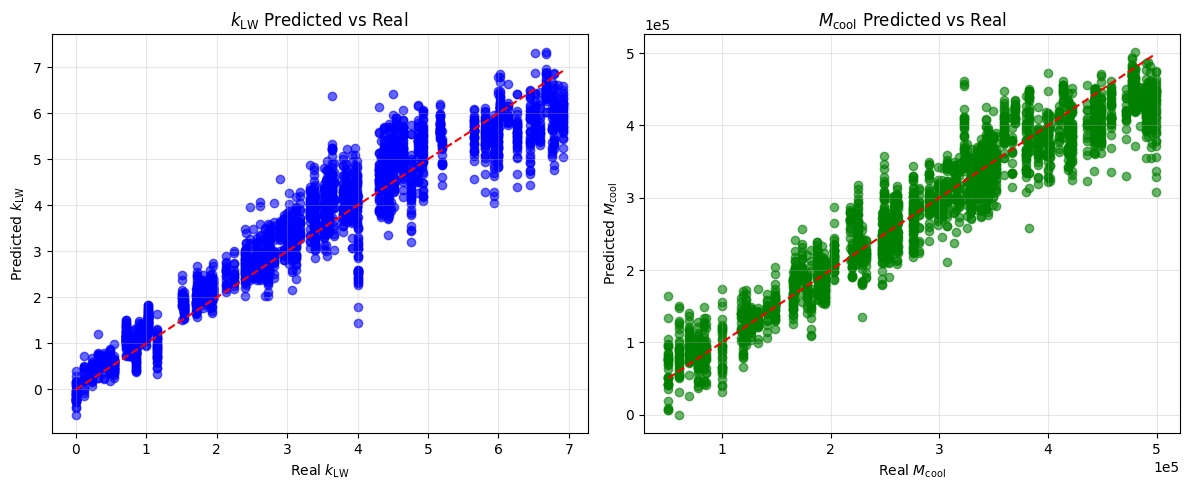

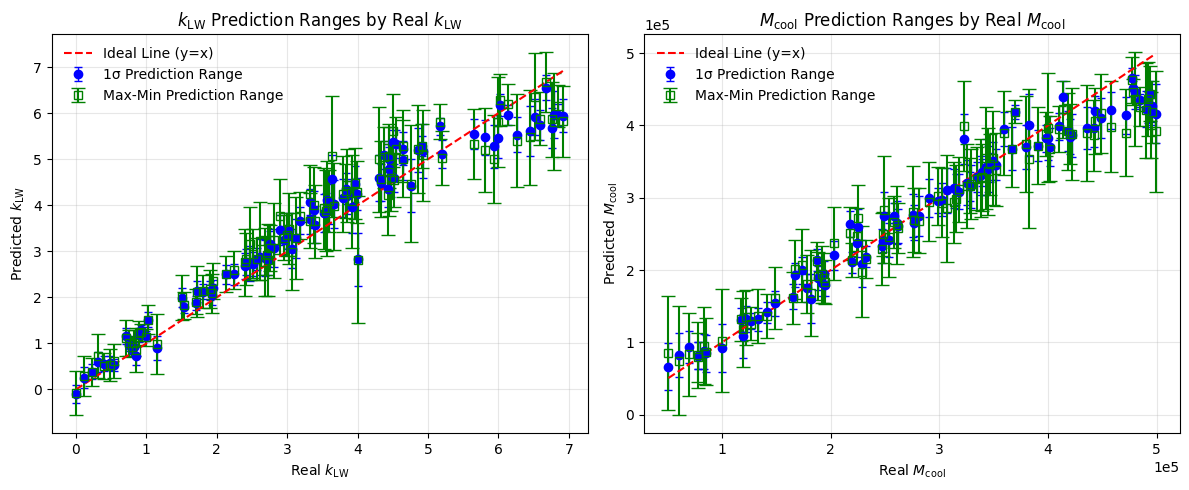

k_LW 分组统计（真实 k_LW -> 预测 k_LW 范围）：
k_LW_real=0.00: mean=-0.0947, 1σ=[-0.2930, 0.1036], max-min=[-0.5579, 0.4119] (样本数: 36)
k_LW_real=0.12: mean=0.2598, 1σ=[0.0389, 0.4806], max-min=[-0.1432, 0.7349] (样本数: 18)
k_LW_real=0.23: mean=0.3850, 1σ=[0.2225, 0.5475], max-min=[0.0713, 0.6925] (样本数: 18)
k_LW_real=0.32: mean=0.6000, 1σ=[0.3798, 0.8203], max-min=[0.2402, 1.2015] (样本数: 18)
k_LW_real=0.40: mean=0.5613, 1σ=[0.4052, 0.7175], max-min=[0.2378, 0.7883] (样本数: 18)
k_LW_real=0.49: mean=0.5705, 1σ=[0.4227, 0.7183], max-min=[0.1916, 0.8744] (样本数: 36)
k_LW_real=0.54: mean=0.5277, 1σ=[0.3943, 0.6611], max-min=[0.2549, 0.9841] (样本数: 36)
k_LW_real=0.71: mean=1.1599, 1σ=[0.9876, 1.3322], max-min=[0.7289, 1.5072] (样本数: 54)
k_LW_real=0.76: mean=0.9562, 1σ=[0.8291, 1.0834], max-min=[0.7295, 1.2861] (样本数: 36)
k_LW_real=0.79: mean=0.8740, 1σ=[0.7631, 0.9849], max-min=[0.6996, 1.1541] (样本数: 18)
k_LW_real=0.83: mean=0.9245, 1σ=[0.8086, 1.0404], max-min=[0.7187, 1.2898] (样本数: 36)
k_LW_real=0.86: mean=0.7289

In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# MODIFIED: 设置学术论文字体和样式（全局配置）
plt.rcParams['font.size'] = 10  # 默认字体大小10pt
plt.rcParams['axes.titlesize'] = 12  # 标题12pt
plt.rcParams['axes.labelsize'] = 10  # 轴标签10pt
plt.rcParams['xtick.labelsize'] = 10  # x轴刻度10pt
plt.rcParams['ytick.labelsize'] = 10  # y轴刻度10pt
plt.rcParams['legend.fontsize'] = 10  # 图例10pt
plt.rcParams['lines.linewidth'] = 1.5  # 线宽1.5pt
plt.rcParams['lines.markersize'] = 6  # 标记大小6pt

# 加载数据（仅测试集）
_, _, test_loader = load_data()

# 初始化模型并加载最佳权重
model = CNN()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
model.load_state_dict(torch.load('best_model_D.pt'))
model.eval()

# 测试模型，获取预测和真实值
test_loss, test_mae_klw, test_mae_mcool, predictions, trues = test_model(model, test_loader, w_klw=1.0, w_mcool=1.0)

# 反归一化
label_stats = torch.load('AngularPS/processed_tensors/modelD/label_stats.pt')
mean = label_stats['mean']  # [klw_mean, mcool_mean]
std = label_stats['std']    # [klw_std, mcool_std]
predictions = predictions * std.numpy() + mean.numpy()  # 形状: (900, 2)
trues = trues * std.numpy() + mean.numpy()             # 形状: (900, 2)

# 1. 可视化预测结果：散点图比较预测值 vs 真实值（保持原样，但受益于全局字体）
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# k_LW的散点图
axes[0].scatter(trues[:, 0], predictions[:, 0], alpha=0.6, color='blue')
axes[0].plot([trues[:, 0].min(), trues[:, 0].max()], [trues[:, 0].min(), trues[:, 0].max()], 'r--', lw=1.5)
axes[0].set_xlabel('Real $k_{\mathrm{LW}}$')
axes[0].set_ylabel('Predicted $k_{\mathrm{LW}}$')
axes[0].set_title('$k_{\mathrm{LW}}$ Predicted vs Real')
axes[0].grid(True, alpha=0.3)
# M_cool的散点图（使用科学计数法）
axes[1].scatter(trues[:, 1], predictions[:, 1], alpha=0.6, color='green')
axes[1].plot([trues[:, 1].min(), trues[:, 1].max()], [trues[:, 1].min(), trues[:, 1].max()], 'r--', lw=1.5)
axes[1].set_xlabel('Real $M_{\mathrm{cool}}$')
axes[1].set_ylabel('Predicted $M_{\mathrm{cool}}$')
axes[1].set_title('$M_{\mathrm{cool}}$ Predicted vs Real')
axes[1].ticklabel_format(style='sci', axis='both', scilimits=(0,0))  # 科学计数法
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('prediction_scatter_10000.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. 误差棒图：按真实值分组，计算对应预测值的范围（MODIFIED: 添加1sigma std范围）
# 第一张：按真实 k_LW 分组，计算预测 k_LW 的均值、std、max和min
unique_klw_real = np.unique(trues[:, 0])
unique_klw_real.sort()
mean_klw_pred = []  # MODIFIED: 新增均值
std_klw_pred = []   # MODIFIED: 新增标准差
max_klw_pred = []
min_klw_pred = []
sample_counts_klw = []
for klw_real in unique_klw_real:
    mask = np.isclose(trues[:, 0], klw_real, atol=1e-4)
    group_klw_preds = predictions[mask, 0]
    
    if len(group_klw_preds) > 1:  # MODIFIED: 至少2个样本才能计算std
        mean_klw_pred.append(np.mean(group_klw_preds))
        std_klw_pred.append(np.std(group_klw_preds))  # 1sigma = std
        max_klw_pred.append(np.max(group_klw_preds))
        min_klw_pred.append(np.min(group_klw_preds))
        sample_counts_klw.append(np.sum(mask))
    else:
        mean_klw_pred.append(np.nan)
        std_klw_pred.append(0)  # MODIFIED: std设为0，避免NaN
        max_klw_pred.append(np.nan)
        min_klw_pred.append(np.nan)
        sample_counts_klw.append(len(group_klw_preds))
mean_klw_pred = np.array(mean_klw_pred)
std_klw_pred = np.array(std_klw_pred)
max_klw_pred = np.array(max_klw_pred)
min_klw_pred = np.array(min_klw_pred)
sample_counts_klw = np.array(sample_counts_klw)

# 第二张：按真实 M_cool 分组，计算预测 M_cool 的均值、std、max和min
unique_mcool_real = np.unique(trues[:, 1])
unique_mcool_real.sort()
mean_mcool_pred = []  # MODIFIED: 新增均值
std_mcool_pred = []   # MODIFIED: 新增标准差
max_mcool_pred = []
min_mcool_pred = []
sample_counts_mcool = []
for mcool_real in unique_mcool_real:
    mask = np.isclose(trues[:, 1], mcool_real, atol=1e-4)
    group_mcool_preds = predictions[mask, 1]
    
    if len(group_mcool_preds) > 1:
        mean_mcool_pred.append(np.mean(group_mcool_preds))
        std_mcool_pred.append(np.std(group_mcool_preds))  # 1sigma = std
        max_mcool_pred.append(np.max(group_mcool_preds))
        min_mcool_pred.append(np.min(group_mcool_preds))
        sample_counts_mcool.append(np.sum(mask))
    else:
        mean_mcool_pred.append(np.nan)
        std_mcool_pred.append(0)
        max_mcool_pred.append(np.nan)
        min_mcool_pred.append(np.nan)
        sample_counts_mcool.append(len(group_mcool_preds))
mean_mcool_pred = np.array(mean_mcool_pred)
std_mcool_pred = np.array(std_mcool_pred)
max_mcool_pred = np.array(max_mcool_pred)
min_mcool_pred = np.array(min_mcool_pred)
sample_counts_mcool = np.array(sample_counts_mcool)

# 绘制误差棒图（MODIFIED: 双误差棒 + 学术样式）
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# 第一张：k_LW 误差棒图
# MODIFIED: 添加1sigma (std) 误差棒（蓝色，细线）
valid_idx_klw = ~np.isnan(mean_klw_pred)  # 只绘制有效组
axes[0].errorbar(unique_klw_real[valid_idx_klw], mean_klw_pred[valid_idx_klw], 
                 yerr=std_klw_pred[valid_idx_klw], fmt='o', capsize=3, color='blue', 
                 linewidth=1, elinewidth=1, markersize=6, label='1σ Prediction Range')
# 原max-min范围（绿色，粗线）
axes[0].errorbar(unique_klw_real[valid_idx_klw], (max_klw_pred[valid_idx_klw] + min_klw_pred[valid_idx_klw]) / 2, 
                 yerr=[(max_klw_pred[valid_idx_klw] - min_klw_pred[valid_idx_klw]) / 2], 
                 fmt='s', capsize=5, color='green', markerfacecolor='none', 
                 linewidth=1.5, elinewidth=1.5, markersize=6, label='Max-Min Prediction Range')
axes[0].plot(unique_klw_real, unique_klw_real, 'r--', lw=1.5, label='Ideal Line (y=x)')
axes[0].set_xlabel('Real $k_{\mathrm{LW}}$')
axes[0].set_ylabel('Predicted $k_{\mathrm{LW}}$')
axes[0].set_title('$k_{\mathrm{LW}}$ Prediction Ranges by Real $k_{\mathrm{LW}}$')
axes[0].legend(frameon=False)  # 无边框图例
axes[0].grid(True, alpha=0.3)

# 第二张：M_cool 误差棒图
# MODIFIED: 添加1sigma (std) 误差棒（蓝色，细线）
valid_idx_mcool = ~np.isnan(mean_mcool_pred)
axes[1].errorbar(unique_mcool_real[valid_idx_mcool], mean_mcool_pred[valid_idx_mcool], 
                 yerr=std_mcool_pred[valid_idx_mcool], fmt='o', capsize=3, color='blue', 
                 linewidth=1, elinewidth=1, markersize=6, label='1σ Prediction Range')
# 原max-min范围（绿色，粗线）
axes[1].errorbar(unique_mcool_real[valid_idx_mcool], (max_mcool_pred[valid_idx_mcool] + min_mcool_pred[valid_idx_mcool]) / 2, 
                 yerr=[(max_mcool_pred[valid_idx_mcool] - min_mcool_pred[valid_idx_mcool]) / 2], 
                 fmt='s', capsize=5, color='green', markerfacecolor='none', 
                 linewidth=1.5, elinewidth=1.5, markersize=6, label='Max-Min Prediction Range')
axes[1].plot(unique_mcool_real, unique_mcool_real, 'r--', lw=1.5, label='Ideal Line (y=x)')
axes[1].set_xlabel('Real $M_{\mathrm{cool}}$')
axes[1].set_ylabel('Predicted $M_{\mathrm{cool}}$')
axes[1].set_title('$M_{\mathrm{cool}}$ Prediction Ranges by Real $M_{\mathrm{cool}}$')
axes[1].ticklabel_format(style='sci', axis='both', scilimits=(0,0))  # 科学计数法
axes[1].legend(frameon=False)  # 无边框图例
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('error_bar_plot.png', dpi=300, bbox_inches='tight')
plt.show()

# 打印分组统计（MODIFIED: 添加std信息）
print("k_LW 分组统计（真实 k_LW -> 预测 k_LW 范围）：")
for i, klw_real in enumerate(unique_klw_real):
    if not np.isnan(mean_klw_pred[i]):
        print(f"k_LW_real={klw_real:.2f}: mean={mean_klw_pred[i]:.4f}, 1σ=[{mean_klw_pred[i]-std_klw_pred[i]:.4f}, {mean_klw_pred[i]+std_klw_pred[i]:.4f}], "
              f"max-min=[{min_klw_pred[i]:.4f}, {max_klw_pred[i]:.4f}] (样本数: {sample_counts_klw[i]})")
print("\nM_cool 分组统计（真实 M_cool -> 预测 M_cool 范围）：")
for i, mcool_real in enumerate(unique_mcool_real):
    if not np.isnan(mean_mcool_pred[i]):
        print(f"M_cool_real={mcool_real:.4e}: mean={mean_mcool_pred[i]:.4e}, 1σ=[{mean_mcool_pred[i]-std_mcool_pred[i]:.4e}, {mean_mcool_pred[i]+std_mcool_pred[i]:.4e}], "
              f"max-min=[{min_mcool_pred[i]:.4e}, {max_mcool_pred[i]:.4e}] (样本数: {sample_counts_mcool[i]})")

In [10]:
import pandas as pd
import numpy as np

# --- k_LW 分组：收集所有预测值 ---
klw_groups = []  # 存储每组的信息

for klw_real in unique_klw_real:
    mask = np.isclose(trues[:, 0], klw_real, atol=1e-4)
    group_preds = predictions[mask, 0]  # 该组所有预测的 k_LW 值
    
    if len(group_preds) > 0:  # 只保存有样本的组
        klw_groups.append({
            "k_LW_real": round(klw_real, 4),
            "sample_count": len(group_preds),
            "k_LW_pred_mean": np.mean(group_preds),
            "k_LW_pred_std": np.std(group_preds),
            "k_LW_pred_min": np.min(group_preds),
            "k_LW_pred_max": np.max(group_preds),
            "all_k_LW_predictions": group_preds.tolist()  # 保存所有单个预测值（列表）
        })

df_klw_full = pd.DataFrame(klw_groups)

# 保存为 CSV（pandas 会自动将列表转为字符串显示，但内容完整保留）
df_klw_full.to_csv("k_LW_group_stats_nonoise_D.csv", index=False)
print("已保存：k_LW_group_all_predictions.csv")
print(f"一共 {len(df_klw_full)} 个 k_LW 分组，每组所有预测值已完整保存。")
print(df_klw_full[['k_LW_real', 'sample_count', 'k_LW_pred_mean', 'k_LW_pred_std', 'k_LW_pred_min', 'k_LW_pred_max']])  # 预览统计列


# --- M_cool 分组：收集所有预测值 ---
mcool_groups = []

for mcool_real in unique_mcool_real:
    mask = np.isclose(trues[:, 1], mcool_real, atol=1e-4)
    group_preds = predictions[mask, 1]  # 该组所有预测的 M_cool 值
    
    if len(group_preds) > 0:
        mcool_groups.append({
            "M_cool_real": mcool_real,  # 科学计数法，保持原样
            "sample_count": len(group_preds),
            "M_cool_pred_mean": np.mean(group_preds),
            "M_cool_pred_std": np.std(group_preds),
            "M_cool_pred_min": np.min(group_preds),
            "M_cool_pred_max": np.max(group_preds),
            "all_M_cool_predictions": group_preds.tolist()  # 所有单个预测值
        })

df_mcool_full = pd.DataFrame(mcool_groups)

df_mcool_full.to_csv("M_cool_group_stats_nonoise_D.csv", index=False)
print("\n已保存：M_cool_group_all_predictions.csv")
print(f"一共 {len(df_mcool_full)} 个 M_cool 分组，每组所有预测值已完整保存。")
print(df_mcool_full[['M_cool_real', 'sample_count', 'M_cool_pred_mean', 'M_cool_pred_std', 'M_cool_pred_min', 'M_cool_pred_max']])

已保存：k_LW_group_all_predictions.csv
一共 95 个 k_LW 分组，每组所有预测值已完整保存。
    k_LW_real  sample_count  k_LW_pred_mean  k_LW_pred_std  k_LW_pred_min  \
0        0.00            36       -0.094704       0.198256      -0.557894   
1        0.12            18        0.259760       0.220838      -0.143246   
2        0.23            18        0.384986       0.162520       0.071324   
3        0.32            18        0.600048       0.220236       0.240234   
4        0.40            18        0.561337       0.156186       0.237843   
..        ...           ...             ...            ...            ...   
90       6.68            36        6.555660       0.279402       6.017726   
91       6.76            18        5.680459       0.431645       5.053571   
92       6.79            36        5.967756       0.505267       4.770609   
93       6.85            18        5.963079       0.232397       5.696213   
94       6.92            36        5.946041       0.350804       5.047331   

    k_LW_p

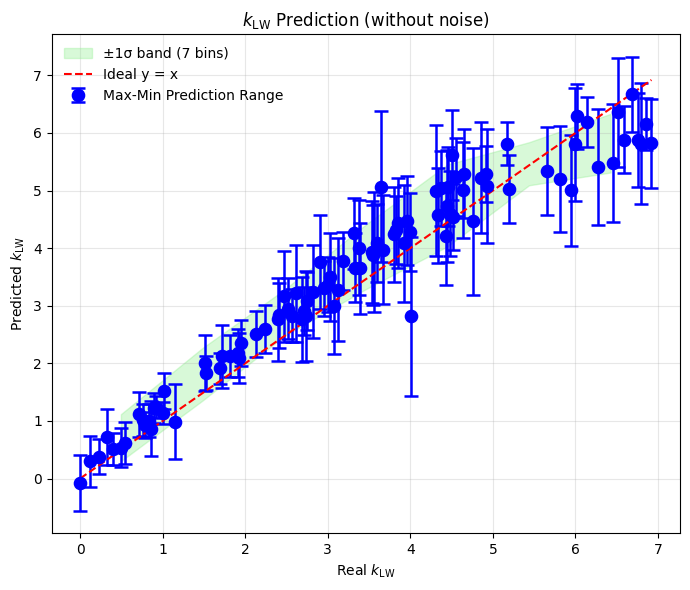

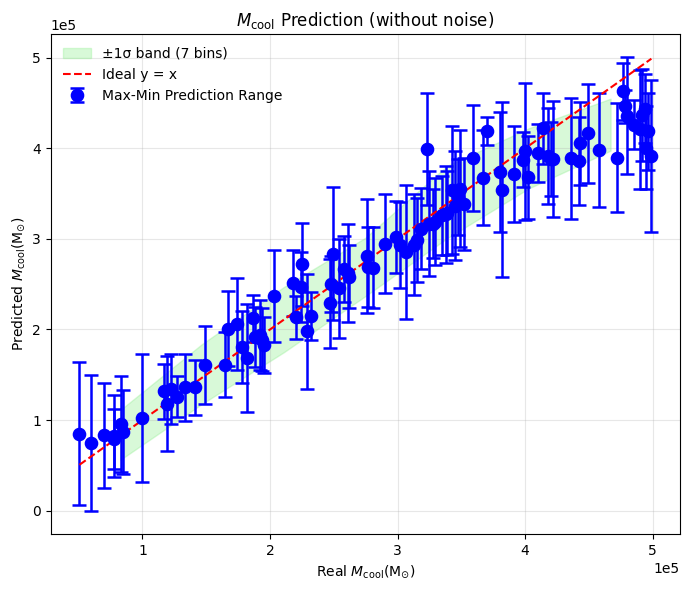

In [11]:
# ====================== 新代码块：四张独立图（Max-Min errorbar 实心中心 + 7bin 1σ色带） ======================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 设置学术风格
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['lines.markersize'] = 6
plt.rcParams['text.usetex'] = False

# 读取数据（文件名完全保持原样）
df_k_nonoise   = pd.read_csv("k_LW_group_stats_nonoise_D.csv")    # 无噪音
df_m_nonoise   = pd.read_csv("M_cool_group_stats_nonoise_D.csv")  # 无噪音

# --------------------- 函数：绘制单张独立图（Max-Min errorbar 实心中心） ---------------------
def plot_maxmin_with_sigma_band(df, real_col, min_col, max_col, mean_col, std_col,
                                title, xlabel, ylabel, filename, use_sci=False, nbins=7):
    df_valid = df.dropna(subset=[min_col, max_col])
    
    if len(df_valid) == 0:
        print(f"警告：{filename} 无有效数据")
        return
    
    real = df_valid[real_col].values
    pred_min = df_valid[min_col].values
    pred_max = df_valid[max_col].values
    pred_mean = df_valid[mean_col].values if mean_col in df_valid else (pred_min + pred_max)/2
    pred_std = df_valid[std_col].values if std_col in df_valid else np.zeros_like(pred_min)
    
    # 创建图片
    fig, ax = plt.subplots(figsize=(7, 6))
    
    # === 7个均匀bin的平滑 ±1σ 色带 ===
    overall_min = real.min()
    overall_max = real.max()
    bin_edges = np.linspace(overall_min, overall_max, nbins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    lowers = np.full(nbins, np.nan)
    uppers = np.full(nbins, np.nan)
    
    for i in range(nbins):
        mask = (real >= bin_edges[i]) & (real < bin_edges[i+1])
        if np.sum(mask) > 1:
            bin_means = pred_mean[mask]
            bin_stds = pred_std[mask]
            combined_mean = np.mean(bin_means)
            combined_std = np.sqrt(np.mean(bin_stds**2) + np.var(bin_means))
            lowers[i] = combined_mean - combined_std
            uppers[i] = combined_mean + combined_std
    
    ax.fill_between(bin_centers, lowers, uppers, color='lightgreen', alpha=0.35, label='±1σ band (7 bins)')
    
    # === Max-Min Prediction Range errorbar（中心实心圆点）===
    mid = (pred_min + pred_max) / 2
    err = (pred_max - pred_min) / 2
    ax.errorbar(real, mid, yerr=err,
                fmt='o', color='blue', capsize=5, markersize=8,
                markerfacecolor='blue', markeredgewidth=1.8, elinewidth=1.8,  # 实心中心 + 粗边/棒
                label='Max-Min Prediction Range')
    
    # 理想线
    ax.plot([overall_min, overall_max], [overall_min, overall_max], 'r--', lw=1.5, label='Ideal y = x')
    
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    if use_sci:
        ax.ticklabel_format(style='sci', axis='both', scilimits=(0,0))
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False)
    
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

# --------------------- 绘制四张独立图 ---------------------

# 2. k_LW 无噪音
plot_maxmin_with_sigma_band(
    df_k_nonoise,
    real_col="k_LW_real",
    min_col="k_LW_pred_min",
    max_col="k_LW_pred_max",
    mean_col="k_LW_pred_mean",
    std_col="k_LW_pred_std",
    title="$k_{\\mathrm{LW}}$ Prediction (without noise)",
    xlabel="Real $k_{\\mathrm{LW}}$",
    ylabel="Predicted $k_{\\mathrm{LW}}$",
    filename="kLW_without_noise_maxmin_D.png"
)

# 4. M_cool 无噪音
plot_maxmin_with_sigma_band(
    df_m_nonoise,
    real_col="M_cool_real",
    min_col="M_cool_pred_min",
    max_col="M_cool_pred_max",
    mean_col="M_cool_pred_mean",
    std_col="M_cool_pred_std",
    title="$M_{\\mathrm{cool}}$ Prediction (without noise)",
    xlabel="Real $M_{\\mathrm{cool}}(\\mathrm{{M_{{\\odot}}}})$",
    ylabel="Predicted $M_{\\mathrm{cool}}(\\mathrm{{M_{{\\odot}}}})$",
    filename="Mcool_without_noise_maxmin_D.png",
    use_sci=True
)


选中的样本组：
真实 k_LW = 2.4700
真实 M_cool = 3.8200e+05 M_⊙
该组样本数量：18


/tmp/ipykernel_3964338/692173974.py:156: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 1])


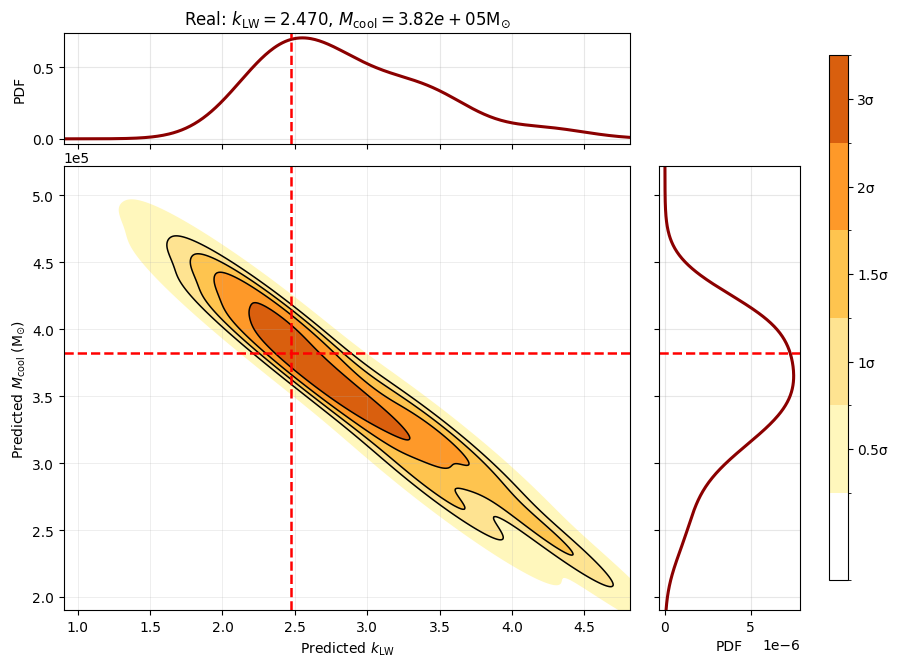


预测统计：
k_LW   = 2.860627 ± 0.527478
M_cool = 3.55997688e+05 ± 4.46949531e+04


In [12]:
# ====================== 最终方案：σ 阶梯纯色填充（地形图风格） ======================

from scipy.stats import gaussian_kde
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm

# ==================== 样本选择（保持不变） ====================
tol = 1e-6
trues_rounded = np.round(trues, decimals=8)
unique_combinations = np.unique(trues_rounded, axis=0)
unique_combinations = unique_combinations[np.lexsort(
    (unique_combinations[:, 1], unique_combinations[:, 0]))
]

selected_real_pair = unique_combinations[38]
print(f"\n选中的样本组：")
print(f"真实 k_LW = {selected_real_pair[0]:.4f}")
print(f"真实 M_cool = {selected_real_pair[1]:.4e} M_⊙")

mask = np.all(np.isclose(trues, selected_real_pair, atol=tol), axis=1)
selected_predictions = predictions[mask]
sample_count = len(selected_predictions)
print(f"该组样本数量：{sample_count}")

pred_klw = selected_predictions[:, 0]
pred_mcool = selected_predictions[:, 1]

# ==================== 画布布局 ====================
fig = plt.figure(figsize=(9.5, 7.5))
gs = gridspec.GridSpec(
    2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
    wspace=0.08, hspace=0.08
)

ax_main = fig.add_subplot(gs[1, 0])
ax_top = fig.add_subplot(gs[0, 0], sharex=ax_main)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

# ==================== 视野范围（完整 3.5σ） ====================
mean_klw, std_klw = np.mean(pred_klw), np.std(pred_klw)
mean_mcool, std_mcool = np.mean(pred_mcool), np.std(pred_mcool)

pad_sigma = 3.5
xmin = mean_klw - pad_sigma * std_klw
xmax = mean_klw + pad_sigma * std_klw
ymin = mean_mcool - pad_sigma * std_mcool
ymax = mean_mcool + pad_sigma * std_mcool

margin_x = 0.03 * (xmax - xmin)
margin_y = 0.03 * (ymax - ymin)
xmin -= margin_x
xmax += margin_x
ymin -= margin_y
ymax += margin_y

ax_main.set_xlim(xmin, xmax)
ax_main.set_ylim(ymin, ymax)

# ==================== 2D KDE ====================
kde = gaussian_kde(np.vstack([pred_klw, pred_mcool]))
X, Y = np.mgrid[xmin:xmax:400j, ymin:ymax:400j]
positions = np.vstack([X.ravel(), Y.ravel()])
Z = np.reshape(kde(positions).T, X.shape)

# ==================== σ 等概率区域计算（核心） ====================
Z_flat = Z.flatten()
idx = np.argsort(Z_flat)[::-1]
Z_sorted = Z_flat[idx]

cdf = np.cumsum(Z_sorted)
cdf /= cdf[-1]

sigma_probs = [0.393, 0.6827, 0.866, 0.9545, 0.9973]
pdf_levels = [Z_sorted[np.searchsorted(cdf, p)] for p in sigma_probs]

levels = [0.0] + sorted(pdf_levels) + [Z.max()]

# ==================== 离散纯色（地形图风格） ====================
sigma_colors = [
    "#ffffff",  # <0.5σ（背景）
    "#fff7bc",  # 0.5σ
    "#fee391",  # 1σ
    "#fec44f",  # 1.5σ
    "#fe9929",  # 2σ
    "#d95f0e",  # 3σ（核心）
]


cmap = ListedColormap(sigma_colors)
norm = BoundaryNorm(levels, cmap.N)

# ==================== 主图：σ 阶梯填色 ====================
cf = ax_main.contourf(
    X, Y, Z,
    levels=levels,
    cmap=cmap,
    norm=norm,
    antialiased=True
)

# σ 边界线（可选但强烈推荐）
ax_main.contour(
    X, Y, Z,
    levels=levels[2:-1],
    colors='k',
    linewidths=1.1
)

# ==================== 真实值 ====================
ax_main.axvline(selected_real_pair[0], color='red', ls='--', lw=1.8)
ax_main.axhline(selected_real_pair[1], color='red', ls='--', lw=1.8)

ax_main.set_xlabel('Predicted $k_{\\mathrm{LW}}$')
ax_main.set_ylabel('Predicted $M_{\\mathrm{cool}}$ ($\\mathrm{{M_{{\\odot}}}}$)')
ax_main.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
ax_main.grid(True, alpha=0.3, lw=0.5)

# ==================== 上方 1D KDE ====================
kde_klw = gaussian_kde(pred_klw)
x_klw = np.linspace(xmin, xmax, 400)
ax_top.plot(x_klw, kde_klw(x_klw), color='darkred', lw=2.2)
ax_top.axvline(selected_real_pair[0], color='red', ls='--', lw=1.8)
ax_top.set_ylabel('PDF')
ax_top.set_title(
    f'Real: $k_{{\\mathrm{{LW}}}}={selected_real_pair[0]:.3f}$, '
    f'$M_{{\\mathrm{{cool}}}}={selected_real_pair[1]:.2e} \\mathrm{{M_{{\\odot}}}}$'
)
ax_top.grid(True, alpha=0.3)
ax_top.tick_params(labelbottom=False)

# ==================== 右侧 1D KDE ====================
kde_mcool = gaussian_kde(pred_mcool)
y_mcool = np.linspace(ymin, ymax, 400)
ax_right.plot(kde_mcool(y_mcool), y_mcool, color='darkred', lw=2.2)
ax_right.axhline(selected_real_pair[1], color='red', ls='--', lw=1.8)
ax_right.set_xlabel('PDF')
ax_right.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
ax_right.tick_params(labelleft=False)
ax_right.grid(True, alpha=0.3)

# ==================== 颜色条（σ 标注） ====================
cbar_ax = fig.add_axes([0.93, 0.15, 0.02, 0.7])
cbar = fig.colorbar(cf, cax=cbar_ax)
cbar.set_ticks([
    (levels[i] + levels[i+1]) / 2 for i in range(1, 6)
])

cbar.set_ticklabels([
    '0.5σ', '1σ', '1.5σ', '2σ', '3σ'
])

cbar.set_label(' ')

plt.tight_layout(rect=[0, 0, 0.91, 1])
plt.savefig('2d_prediction_density_nonoise_fix.png',
            dpi=300, bbox_inches='tight')
plt.show()

# ==================== 统计输出 ====================
print(f"\n预测统计：")
print(f"k_LW   = {mean_klw:.6f} ± {std_klw:.6f}")
print(f"M_cool = {mean_mcool:.8e} ± {std_mcool:.8e}")
